# MAIN COMBINATION
- mpp 1
- fisher robust global comb


# 🔬 Dokumentace metod agregace (Embedding Methods)

Tento přehled vysvětluje logiku názvů a matematické principy metod použitých v analýze **Privacy Risk ($R_s$)**. Každý název je složeninou tří informací: **Algoritmus** + **Zdroj dat** + **Prostorová úprava**.

---

## 1. Matematický algoritmus (Jak se data sčítají)

Tato část určuje, jakým způsobem se tisíce individuálních dlaždic (tiles) „smrsknou“ do jednoho výsledného vektoru pro celý slide.

| Název | Princip | Vlastnosti a Privacy Risk |
| :--- | :--- | :--- |
| **`vlad`** | **Vector of Locally Aggregated Descriptors.** Počítá součet rozdílů (reziduí) mezi každou dlaždicí a jejím nejbližším centrem klastru. | **Nízké riziko.** Nejjednodušší a nejméně detailní metoda. Často slouží jako "baseline" pro anonymitu. |
| **`fisher_mean`** | **„Soft VLAD“.** Sleduje pouze posun těžiště (průměru) dat vůči klastrům. Na rozdíl od VLADu využívá "soft-assignment" (GMM). | **Střední riziko.** U Encoderu 0 (GigaPath) vykazuje nejlepší poměr mezi zachováním informace a ochranou soukromí ($R_s \approx 0.3$). |
| **`fisher_robust`** | **Plnohodnotný Fisherův vektor.** Sleduje posun těžiště (průměr) **i změnu rozptylu** (varianci). Používá normalizaci (sign-squaring, $L_2$). | **Vysoké riziko.** Zachycuje unikátní „texturu“ a variabilitu tkáně pacienta. Téměř vždy dosahuje $R_s \approx 1.0$ (digitální otisk). |



---

## 2. Zdroj dat (Co model z dlaždice „vidí“)

Určuje, která část výstupu z hlubokého modelu (Encoderu) vstupuje do agregace.

| Název | Původní termín | Popis |
| :--- | :--- | :--- |
| **`cls`** | **Classification Token** | Globální příznak dlaždice. Model se snaží shrnout "celkový dojem" z obrázku do jednoho vektoru. |
| **`patch`** | **Spatial Tokens** | Detailní mřížka textur uvnitř dlaždice. Velmi citlivé na mikroskopické změny morfologie. |
| **`global_comb`** | **Hybrid / Default** | Sjednocená data. U Virchowa (Enc 1) jde o spojení CLS + Patch. U GigaPathu (Enc 0) a UNI2 (Enc 2) jde o jejich standardní 1536-dim výstup. |

---

## 3. Prostorová úprava (Kontext sousedství)

| Název | Popis | Dopad na analýzu |
| :--- | :--- | :--- |
| *(bez přípony)* | **Standardní přístup** | Každá dlaždice je zpracována izolovaně. Výsledek je náchylnější k náhodnému technickému šumu. |
| **`_super`** | **Super-tiles** | Hodnota každé dlaždice se před výpočtem zprůměruje s jejími nejbližšími sousedy (prostorové vyhlazení). | **Zvyšuje identifikovatelnost.** Odstraněním šumu vyniknou stabilní biologické vzory, které lépe identifikují pacienta. |



---

## 💡 Klíčové interpretace výsledků

1. **Trade-off u GigaPathu (Encoder 0):** Identita pacienta je u tohoto modelu uložena primárně v **rozptylu (variabilitě)** tkáně. Pokud použijeme `fisher_mean` (Soft VLAD), tuto variabilitu zahodíme, čímž dramaticky snížíme riziko odhalení pacienta, aniž bychom ztratili globální informaci o tkáni.
2. **Citlivost Virchowa (Encoder 1):** U tohoto modelu je informace o pacientovi tak silná, že je přítomna v průměru i v rozptylu. Téměř všechny metody u něj vedou k vysokému $R_s$.
3. **Role Super-tiles:** Ačkoliv vyhlazení dat vypadá jako "anonymizace", v histopatologii funguje opačně – čistí data tak efektivně, až z nich lépe vystupuje unikátní biologický profil konkrétního člověka.

# MPP graphs

## HELP TOOLS

In [5]:
import os
# Omezíme paralelismus na 4 vlákna (ideální pro login node)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Teprve TEĎ importuj zbytek
import pyarrow.parquet as pq
import numpy as np
import faiss

In [ ]:
import urllib.parse
import re
import numpy as np
import pyarrow.parquet as pq
import faiss

def load_data_with_patient_parsing(parquet_path, embedding_col="vlad_raw"):
    # Načteme vše potřebné
    table = pq.read_table(parquet_path)
    print(f"Načteno {len(table)} řádků z {parquet_path}")
    table = pq.read_table(parquet_path, columns=[embedding_col, "__filename"])

    # Do těchto seznamů budeme ukládat jen "OK" data
    clean_embeddings = []
    clean_patient_ids = []
    clean_section_nums = []
    
    # Projdeme data řádek po řádku
    for i in range(len(table)):
        raw_filename = table.column("__filename")[i].as_py()
        
        # 1. Dekódování URL
        decoded_path = urllib.parse.unquote(raw_filename)
        filename = decoded_path.split('/')[-1].upper()
        
        # 2. FILTRY (Markery a Sub-řezy typu -1, -2)
        bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
        if any(m in filename for m in bad_markers):
            continue
        if re.search(r'(?:VEN|DORS|VENT)\d+-', filename):
            continue
            
        # 3. EXTRAKCE ČÍSLA ŘEZU A PACIENTA
        match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
        if match:
            num = int(match.group(1))
            # Ignorujeme podezřelé řezy nad 12 (nebo je omezíme)
            if num > 13: 
                continue
                
            # Pacient ID ze složky (předposlední část cesty)
            parts = decoded_path.split('/')
            p_id = parts[-2] if len(parts) > 1 else "unknown"
            
            # Pokud vše prošlo, uložíme si embedding a info
            emb = table.column(embedding_col)[i].as_py()
            clean_embeddings.append(emb)
            clean_patient_ids.append(p_id)
            clean_section_nums.append(num)

    # Převod na numpy pole
    embeddings = np.array(clean_embeddings, dtype='float32')
    patient_ids = np.array(clean_patient_ids)
    section_nums = np.array(clean_section_nums)
    
    # Normalizace pro FAISS (pokud používáš IndexFlatIP)
    if len(embeddings) > 0:
        faiss.normalize_L2(embeddings)
    
    print(f"Původně načteno: {len(table)} řádků")
    print(f"Po filtraci zbylo: {len(embeddings)} čistých řezů")
    print(f"Unikátních pacientů: {len(np.unique(patient_ids))}")
    
    return patient_ids, section_nums, embeddings

In [ ]:
import numpy as np
import faiss

def run_similarity_attack(embeddings, metadata_df, top_k=1):
    """
    Provede útok f(p). 
    embeddings: numpy array (N, dim)
    metadata_df: pandas DF s patient_id pro každý řádek v embeddings
    """
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim) # Kosinová podobnost (pokud jsou vektory normované)
    index.add(embeddings)
    
    # Hledáme top_k + 1 (protože první výsledek bude vždy ta stejná sonda)
    distances, indices = index.search(embeddings, top_k + 1)
    
    # Vezmeme druhý nejbližší (index 1), abychom se neporovnávali sami se sebou
    top_1_indices = indices[:, 1]
    
    # Mapujeme indexy zpět na Patient ID
    patient_ids = metadata_df['patient_id'].values
    predictions = patient_ids[top_1_indices]
    
    results = metadata_df.copy()
    results['predicted_patient_id'] = predictions
    return results

In [ ]:
def calculate_rs_pure_python(patient_ids, embeddings):
    n, dim = embeddings.shape
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    
    # Hledáme 2 nejbližší sousedy
    _, indices = index.search(embeddings, 2)
    
    # ID pacienta u nejbližšího souseda (vylučujeme sami sebe na indexu 0)
    neighbor_indices = indices[:, 1]
    predicted_ids = patient_ids[neighbor_indices]
    
    # Identifikace úspěšných útoků na úrovni sondy
    correct_mask = (patient_ids == predicted_ids)
    
    # Ruční "groupby" podle patient_id
    # Vytvoříme si set zranitelných pacientů
    vulnerable_patients = set()
    all_patients = set(patient_ids)
    
    for i in range(len(patient_ids)):
        if correct_mask[i]:
            vulnerable_patients.add(patient_ids[i])
            
    num_vulnerable = len(vulnerable_patients)
    total_patients = len(all_patients)
    rs = num_vulnerable / total_patients
    
    print(f"--- Výsledek Rs (Pure Python/Arrow) ---")
    print(f"Celkem unikátních pacientů: {total_patients}")
    print(f"Zranitelných pacientů: {num_vulnerable}")
    print(f"Finální R_s: {rs:.4f}")
    
    return rs

In [ ]:
enc = ["1", "2"]
mpp = ["20", "10", "05"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
]

types = ["slides_v4"]


# TOP-1 R_s attack

In [10]:
import gc


results_data = []

for e in enc:
    for m in mpp:
        for t in types:
            # Dynamicky slož cestu (uprav podle toho, jak to máš na disku)
            # Předpokládám formát názvu složky podobný tomu, co jsi posílal
            current_path = f"/data/fs201053/jb88526/privagams_enc{e}_mpp{m}_enhanced_{t}"
            
            if not os.path.exists(current_path):
                print(f"Skipping: {current_path} (neexistuje)")
                continue
                
            for col in emb_col:

                print(f"Processing: ENC={e}, MPP={m}, COL={col}...")
                
                try:
                    # Načtení a výpočet (použijeme ty tvoje vyladěné funkce)
                    pids, _, embs = load_data_with_patient_parsing(current_path, embedding_col=col)
                    rs_val = calculate_rs_pure_python(pids, embs)
                    del pids, embs  # Vyčistíme ty obří matice
                    gc.collect()    
                    
                    results_data.append({
                        "enc": f"Encoder {e}",
                        "mpp": m,
                        "method": col,
                        "rs_value": rs_val,
                        "type": t
                    })
                except Exception as ex:
                    print(f"Chyba u {current_path}, {col}: {ex}")

# Převedeme na DataFrame pro snadné kreslení
import pandas as pd
df_results = pd.DataFrame(results_data)

Processing: ENC=1, MPP=20, COL=vlad_default...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc1_mpp20_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_s: 0.9875
Processing: ENC=1, MPP=20, COL=vlad_default_super...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc1_mpp20_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_s: 0.9875
Processing: ENC=1, MPP=20, COL=fisher_default...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc1_mpp20_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_

/tmp/ipykernel_3646910/2295953775.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)
/tmp/ipykernel_3646910/2295953775.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)
/tmp/ipykernel_3646910/2295953775.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)
/tmp/ipykernel_3646910/2295953775.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)


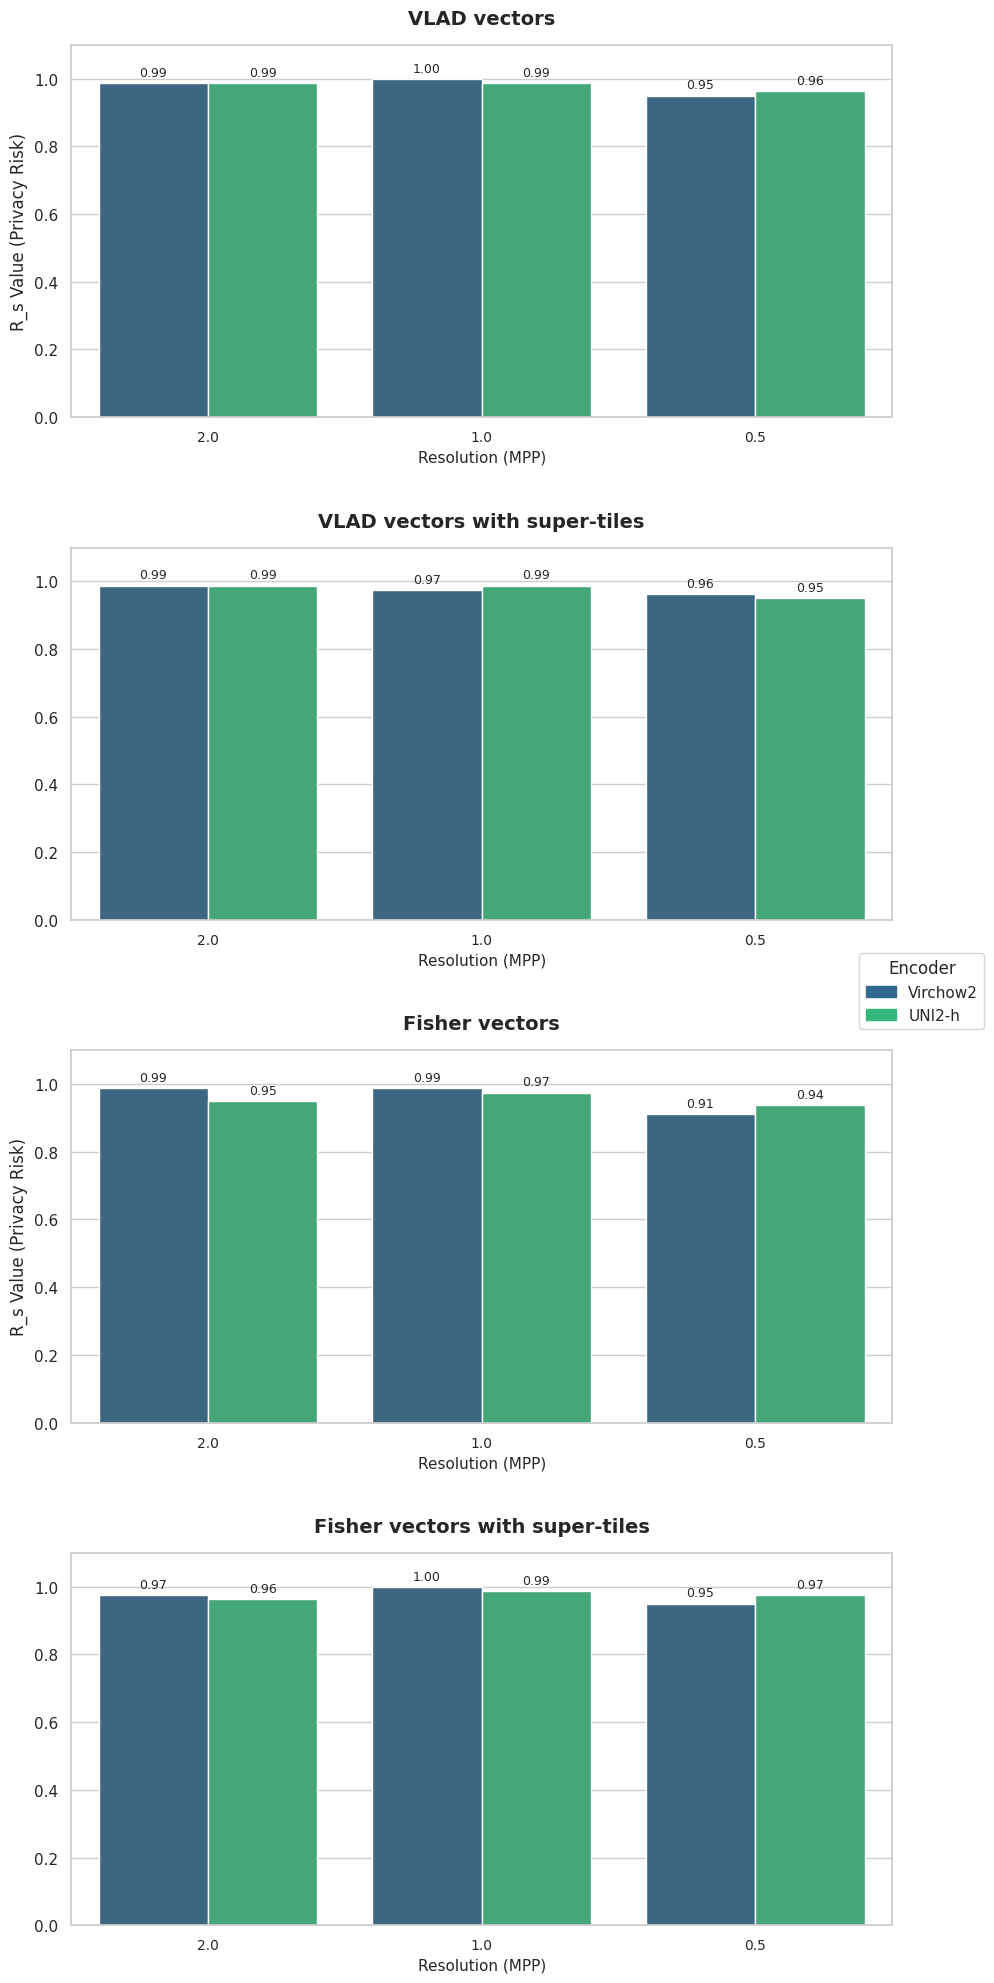

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Příprava dat a figurky
sns.set_theme(style="whitegrid")
methods = df_results['method'].unique()
fig, axes = plt.subplots(4, 1, figsize=(10, 20), sharey=True)
axes_flat = axes.flatten()

# Definice barev pro Enkodéry (aby byly konzistentní)
unique_encs = sorted(df_results['enc'].unique())
palette = sns.color_palette("viridis", len(unique_encs))
color_map = {enc: palette[i] for i, enc in enumerate(unique_encs)}

# 2. Vykreslení každého grafu zvlášť
for i, method in enumerate(methods):
    ax = axes_flat[i]
    method_data = df_results[df_results['method'] == method]
    
    # Použijeme klasický barplot s dodge=True (sloupce vedle sebe)
    sns.barplot(
        data=method_data,
        x="mpp",
        y="rs_value",
        hue="enc",
        palette=color_map,
        ax=ax,
        dodge=True  # Tohle zajistí, že nebudou přes sebe
    )
    
    # Přidání čísel nad sloupce
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    
    # Kosmetika podgrafu
    ax.set_title(method, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Resolution (MPP)", fontsize=11)
    ax.set_ylabel("R_s Value (Privacy Risk)" if i % 2 == 0 else "")
    ax.set_ylim(0, 1.1)
    ax.get_legend().remove() # Odstraníme lokální legendy
    new_labels = ["2.0", "1.0", "0.5"] 
    ax.set_xticklabels(new_labels, fontsize=10)

# 1. Definuj si slovník s hezkými názvy
nice_names = {
    "vlad_default": "VLAD vectors",
    "vlad_default_super": "VLAD vectors with super-tiles",
    "fisher_default": "Fisher vectors",
    "fisher_default_super": "Fisher vectors with super-tiles"
}

# ... začátek cyklu ...
for i, method in enumerate(methods):
    ax = axes_flat[i]
    
    # 2. Vytáhni si hezký název ze slovníku, pokud tam není, nech původní
    display_title = nice_names.get(method, method)
    
    # ... zbytek vykreslování (sns.barplot atd.) ...
    
    # 3. Použij hezký název pro titulek
    ax.set_title(display_title, fontsize=14, fontweight='bold', pad=15)

# 3. RUČNÍ ČISTÁ LEGENDA
# Vytvoříme jen dva čtverečky pro legendu (Encoder 1 a 2)
legend_patches = [
    mpatches.Patch(color=color_map[enc], label=f"{"Virchow2" if enc == "Encoder 1" else "UNI2-h"}") 
    for enc in unique_encs
]

fig.legend(
    handles=legend_patches, 
    title="Encoder", 
    loc='center right', 
    bbox_to_anchor=(1, 0.5),
    fontsize=11
)

# 4. Finální doladění mezer
plt.tight_layout()
plt.subplots_adjust(right=0.9, hspace=0.35, wspace=0.15)

plt.show()

# Embedding graphs

In [5]:
enc = ["1", "2"]
mpp = ["10"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
]

types = ["enhanced_slides_v4", "rmbg_slides_v4", "rmbg_norm_slides_v4", "rmbg_clahe_slides_v4"]


In [14]:
import gc


results_data = []

for e in enc:
    for m in mpp:
        for t in types:
            # Dynamicky slož cestu (uprav podle toho, jak to máš na disku)
            # Předpokládám formát názvu složky podobný tomu, co jsi posílal
            current_path = f"/data/fs201053/jb88526/privagams_enc{e}_mpp{m}_{t}"
            
            if not os.path.exists(current_path):
                print(f"Skipping: {current_path} (neexistuje)")
                continue
                
            for col in emb_col:

                print(f"Processing: ENC={e}, MPP={m}, COL={col}...")
                
                try:
                    # Načtení a výpočet (použijeme ty tvoje vyladěné funkce)
                    pids, _, embs = load_data_with_patient_parsing(current_path, embedding_col=col)
                    rs_val = calculate_rs_pure_python(pids, embs)
                    del pids, embs  # Vyčistíme ty obří matice
                    gc.collect()    
                    
                    results_data.append({
                        "enc": f"Encoder {e}",
                        "mpp": m,
                        "method": col,
                        "rs_value": rs_val,
                        "type": t
                    })
                except Exception as ex:
                    print(f"Chyba u {current_path}, {col}: {ex}")

# Převedeme na DataFrame pro snadné kreslení
import pandas as pd
df_results = pd.DataFrame(results_data)

Processing: ENC=1, MPP=10, COL=vlad_default...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc1_mpp10_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 80
Finální R_s: 1.0000
Processing: ENC=1, MPP=10, COL=vlad_default_super...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc1_mpp10_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 78
Finální R_s: 0.9750
Processing: ENC=1, MPP=10, COL=fisher_default...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc1_mpp10_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_

/tmp/ipykernel_1301578/361393841.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)
/tmp/ipykernel_1301578/361393841.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)
/tmp/ipykernel_1301578/361393841.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)
/tmp/ipykernel_1301578/361393841.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=10)


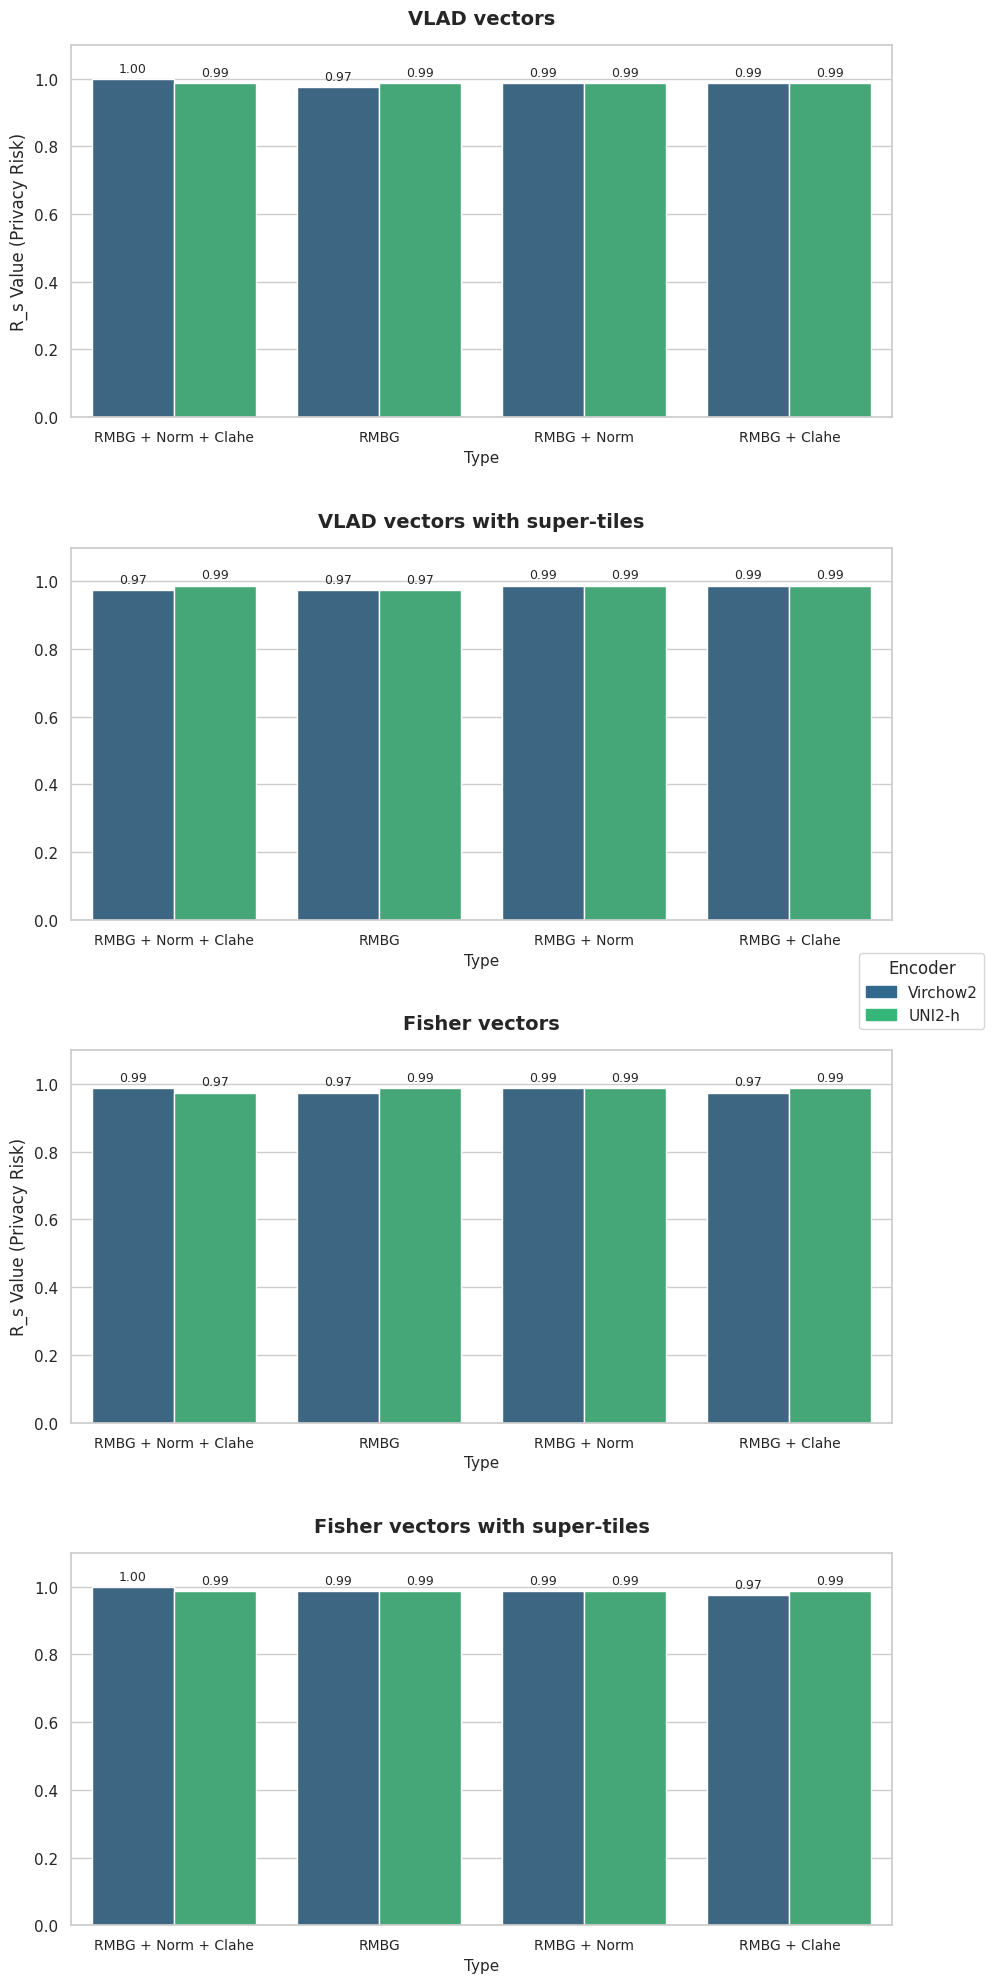

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Příprava dat a figurky
sns.set_theme(style="whitegrid")
methods = df_results['method'].unique()
fig, axes = plt.subplots(4, 1, figsize=(10, 20), sharey=True)
axes_flat = axes.flatten()

# Definice barev pro Enkodéry (aby byly konzistentní)
unique_encs = sorted(df_results['enc'].unique())
palette = sns.color_palette("viridis", len(unique_encs))
color_map = {enc: palette[i] for i, enc in enumerate(unique_encs)}

# 2. Vykreslení každého grafu zvlášť
for i, method in enumerate(methods):
    ax = axes_flat[i]
    method_data = df_results[df_results['method'] == method]
    
    # Použijeme klasický barplot s dodge=True (sloupce vedle sebe)
    sns.barplot(
        data=method_data,
        x="type",
        y="rs_value",
        hue="enc",
        palette=color_map,
        ax=ax,
        dodge=True  # Tohle zajistí, že nebudou přes sebe
    )
    
    # Přidání čísel nad sloupce
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    
    # Kosmetika podgrafu
    ax.set_title(method, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Type", fontsize=11)
    ax.set_ylabel("R_s Value (Privacy Risk)" if i % 2 == 0 else "")
    ax.set_ylim(0, 1.1)
    ax.get_legend().remove() # Odstraníme lokální legendy
    new_labels = ["RMBG + Norm + Clahe", "RMBG", "RMBG + Norm", "RMBG + Clahe"] 
    ax.set_xticklabels(new_labels, fontsize=10)

# 1. Definuj si slovník s hezkými názvy
nice_names = {
    "vlad_default": "VLAD vectors",
    "vlad_default_super": "VLAD vectors with super-tiles",
    "fisher_default": "Fisher vectors",
    "fisher_default_super": "Fisher vectors with super-tiles"
}

for i, method in enumerate(methods):
    ax = axes_flat[i]
    
    # 2. Vytáhni si hezký název ze slovníku, pokud tam není, nech původní
    display_title = nice_names.get(method, method)
    
    # ... zbytek vykreslování (sns.barplot atd.) ...
    
    # 3. Použij hezký název pro titulek
    ax.set_title(display_title, fontsize=14, fontweight='bold', pad=15)


# 3. RUČNÍ ČISTÁ LEGENDA
# Vytvoříme jen dva čtverečky pro legendu (Encoder 1 a 2)
legend_patches = [
    mpatches.Patch(color=color_map[enc], label=f"{"Virchow2" if enc == "Encoder 1" else "UNI2-h"}") 
    for enc in unique_encs
]

fig.legend(
    handles=legend_patches, 
    title="Encoder", 
    loc='center right', 
    bbox_to_anchor=(1, 0.5),
    fontsize=11
)

# 4. Finální doladění mezer
plt.tight_layout()
plt.subplots_adjust(right=0.9, hspace=0.35, wspace=0.15)

plt.show()

# All encoders

In [18]:
enc = ["0", "1", "2", "3"]
mpp = ["10"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
]

types = ["enhanced_slides_v4"]


In [19]:
import gc


results_data = []

for e in enc:
    for m in mpp:
        for t in types:
            # Dynamicky slož cestu (uprav podle toho, jak to máš na disku)
            # Předpokládám formát názvu složky podobný tomu, co jsi posílal
            current_path = f"/data/fs201053/jb88526/privagams_enc{e}_mpp{m}_{t}"
            
            if not os.path.exists(current_path):
                print(f"Skipping: {current_path} (neexistuje)")
                continue
                
            for col in emb_col:

                print(f"Processing: ENC={e}, MPP={m}, COL={col}...")
                
                try:
                    # Načtení a výpočet (použijeme ty tvoje vyladěné funkce)
                    pids, _, embs = load_data_with_patient_parsing(current_path, embedding_col=col)
                    rs_val = calculate_rs_pure_python(pids, embs)
                    del pids, embs  # Vyčistíme ty obří matice
                    gc.collect()    
                    
                    results_data.append({
                        "enc": f"Encoder {e}",
                        "mpp": m,
                        "method": col,
                        "rs_value": rs_val,
                        "type": t
                    })
                except Exception as ex:
                    print(f"Chyba u {current_path}, {col}: {ex}")

# Převedeme na DataFrame pro snadné kreslení
import pandas as pd
df_results = pd.DataFrame(results_data)

Processing: ENC=0, MPP=10, COL=vlad_default...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc0_mpp10_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_s: 0.9875
Processing: ENC=0, MPP=10, COL=vlad_default_super...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc0_mpp10_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_s: 0.9875
Processing: ENC=0, MPP=10, COL=fisher_default...
Načteno 560 řádků z /data/fs201053/jb88526/privagams_enc0_mpp10_enhanced_slides_v4
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_

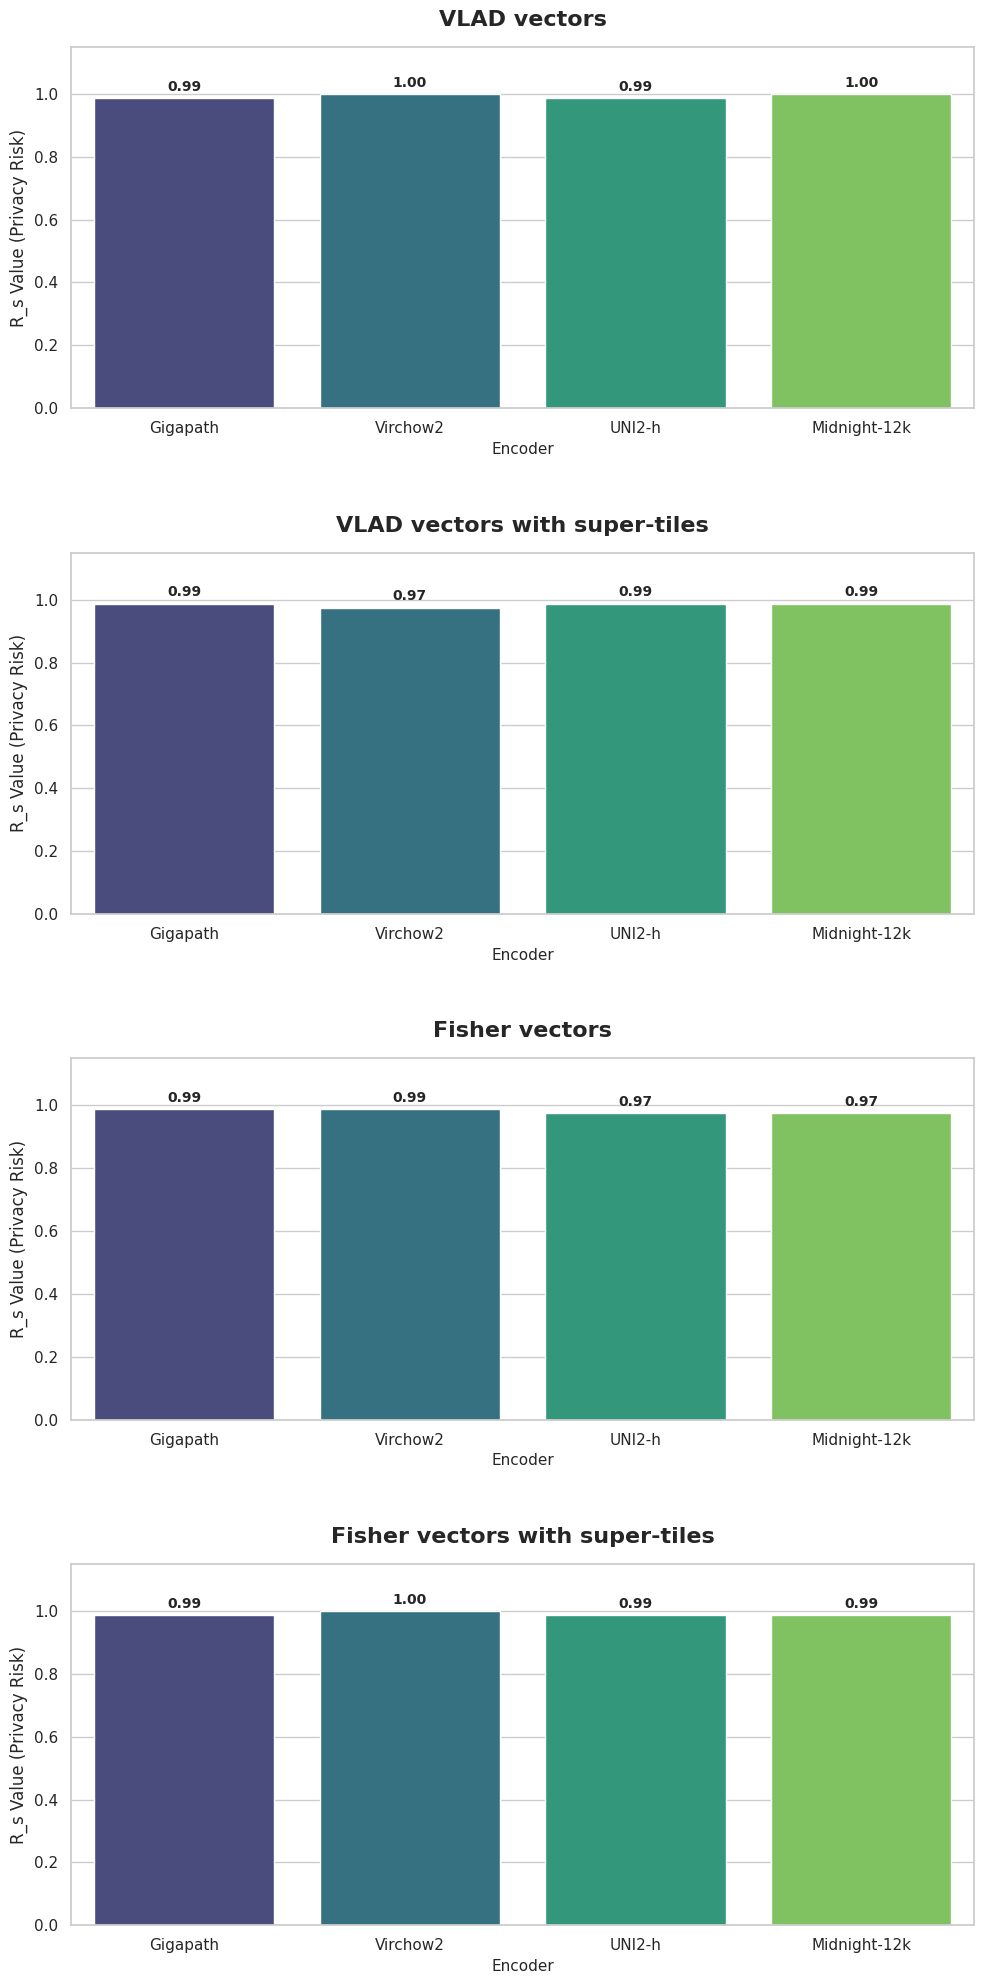

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Slovníky pro hezké názvy
nice_names = {
    "vlad_default": "VLAD vectors",
    "vlad_default_super": "VLAD vectors with super-tiles",
    "fisher_default": "Fisher vectors",
    "fisher_default_super": "Fisher vectors with super-tiles"
}

# Mapování pro popisky osy X (předpokládám, že v 'enc' máš stringy "Encoder 0", "Encoder 1" atd.)
enc_names_map = {
    "Encoder 0": "Gigapath",
    "Encoder 1": "Virchow2",
    "Encoder 2": "UNI2-h",
    "Encoder 3": "Midnight-12k"
}

# 2. Příprava dat a figurky
sns.set_theme(style="whitegrid")
methods = df_results['method'].unique()
fig, axes = plt.subplots(len(methods), 1, figsize=(10, 5 * len(methods)), sharey=True)
axes_flat = axes.flatten()

# Definice barev pro Enkodéry
unique_encs = sorted(df_results['enc'].unique())
palette = sns.color_palette("viridis", len(unique_encs))
color_map = {enc: palette[i] for i, enc in enumerate(unique_encs)}

# 3. Vykreslení
for i, method in enumerate(methods):
    ax = axes_flat[i]
    method_data = df_results[df_results['method'] == method].copy()
    
    # Vytvoření hezkých popisků pro osu X v datech
    method_data['enc_label'] = method_data['enc'].map(enc_names_map).fillna(method_data['enc'])
    
    # Vykreslení barplotu
    sns.barplot(
        data=method_data,
        x="enc_label",  # Teď používáme ty hezké názvy
        y="rs_value",
        hue="enc_label",
        palette="viridis",
        ax=ax,
        dodge=False,    # Máme jeden sloupec na jeden popisek, dodge není potřeba
        legend=False
    )
    
    # Přidání čísel nad sloupce
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')
    
    # Titulek a popisky os
    display_title = nice_names.get(method, method)
    ax.set_title(display_title, fontsize=16, fontweight='bold', pad=15)
    
    ax.set_xlabel("Encoder", fontsize=11)
    ax.set_ylabel("R_s Value (Privacy Risk)")
    ax.set_ylim(0, 1.15)

# 4. Finální doladění
plt.tight_layout()
# hspace zvětšíme, aby se titulky nepletly s popisky osy X horního grafu
plt.subplots_adjust(hspace=0.4) 

plt.show()

## Non-consecutive slides

In [30]:
enc = ["0", "1", "2", "3"]
mpp = ["10"]

emb_cols = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
]

types = ["enhanced_slides_v4"]


<>:157: SyntaxWarning: invalid escape sequence '\D'
<>:157: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1301578/2538750459.py:157: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("Distance between sections ($\Delta$)", fontsize=12)


Zpracovávám Encoder 0...
Zpracovávám Encoder 1...
Zpracovávám Encoder 2...
Zpracovávám Encoder 3...


/tmp/ipykernel_1301578/2538750459.py:142: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_1301578/2538750459.py:142: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_1301578/2538750459.py:142: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_1301578/2538750459.py:142: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_1301578/2538750459.py:142: User

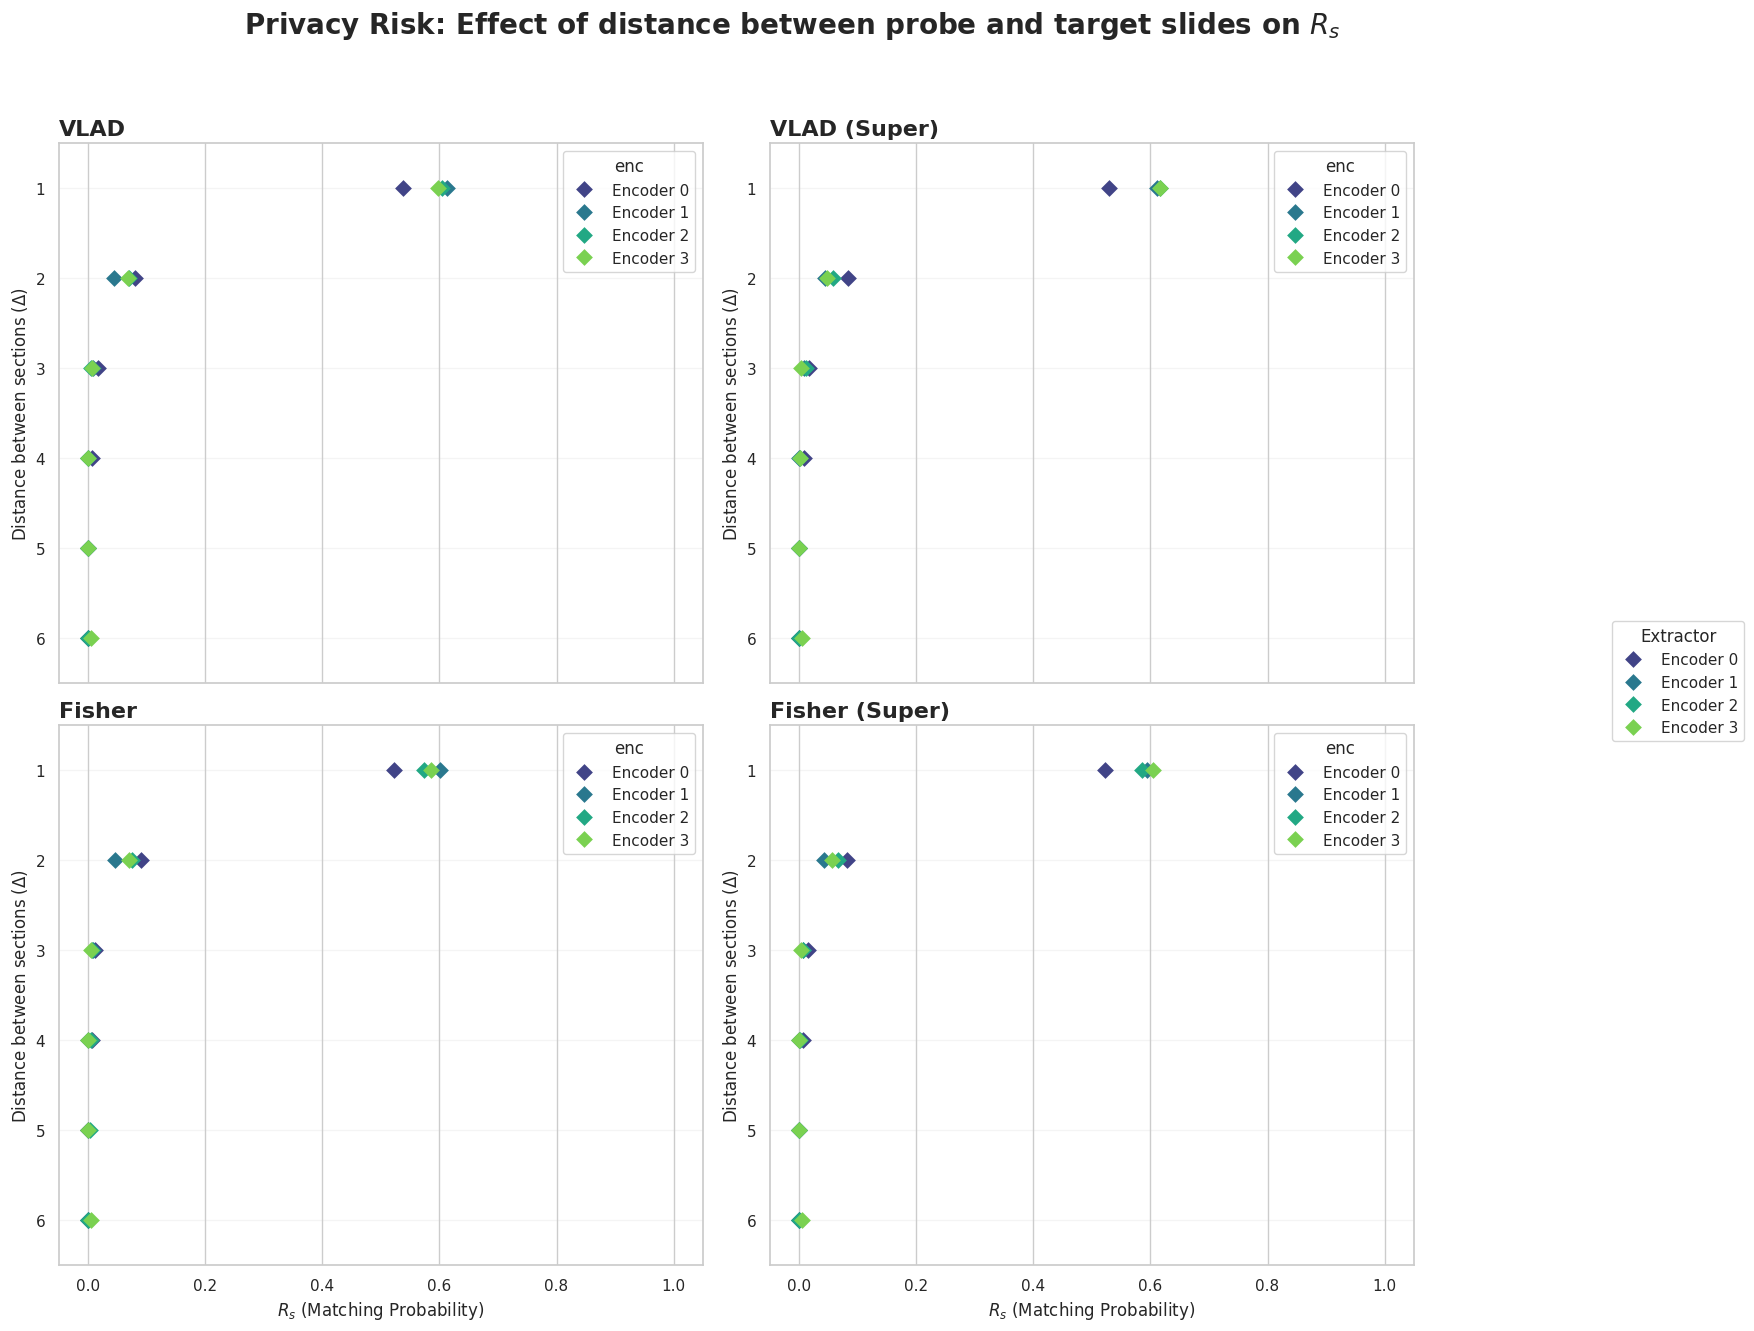

In [37]:
import pandas as pd
import numpy as np
import re
import os
import pyarrow.parquet as pq
import faiss
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. FINÁLNÍ EXTRAKČNÍ LOGIKA ---
def extract_metadata_final(slide_id):
    # Dekódování URL (%2F -> /)
    sid_decoded = urllib.parse.unquote(str(slide_id))
    filename = sid_decoded.split('/')[-1].upper()
    
    # Filtry: Markery a Sub-řezy
    bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
    if any(m in filename for m in bad_markers):
        return None, None, "Marker"
    if re.search(r'(?:VEN|DORS|VENT)\d+-', filename):
        return None, None, "Sub-rez"

    # Extrakce čísla řezu (max 2 cifry, pravidlo 12)
    match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
    if match:
        num = int(match.group(1))
        if num >= 14: num = int(str(num)[0])
        
        # Pacient (číslo složky za annoPaperScanns)
        pat_match = re.search(r'annoPaperScanns/(\d+)/', sid_decoded)
        patient = pat_match.group(1) if pat_match else "Unknown"
        
        return patient, num, "OK"
    
    return None, None, "NoMatch"

# --- 2. FUNKCE PRO VÝPOČET STATISTIK ---
def get_decay_stats_from_clean_df(df_clean, embs_all, method_label, mpp_label, enc_label):
    if df_clean.empty: return []
    
    # Vybereme jen embeddingy pro "OK" řádky
    v_embs = embs_all[df_clean['orig_index'].values].astype('float32')
    faiss.normalize_L2(v_embs)
    
    # FAISS indexování
    index = faiss.IndexFlatIP(v_embs.shape[1])
    index.add(v_embs)
    _, faiss_indices = index.search(v_embs, 2)
    
    # Příprava pro Rs
    inventory = df_clean.groupby('patient_id')['section_num'].apply(set).to_dict()
    decay_entries = []

    # Procházíme výsledky hledání
    for i in range(len(df_clean)):
        neighbor_local_idx = faiss_indices[i, 1]
        row_q = df_clean.iloc[i]
        row_n = df_clean.iloc[neighbor_local_idx]
        
        if row_q['patient_id'] == row_n['patient_id']:
            dist = abs(row_q['section_num'] - row_n['section_num'])
            if 0 < dist <= 10:
                decay_entries.append(dist)

    # Výpočet Rs pro 1-12
    results = []
    for dist in range(1, 14):
        hits = decay_entries.count(dist)
        possible = sum(1 for pid, z_set in inventory.items() for z in z_set 
                      if any(abs(z - oz) == dist for oz in z_set if z != oz))
        
        results.append({
            "enc": enc_label, "mpp": mpp_label, "method": method_label,
            "section_dist": dist, "rs_val": hits/possible if possible > 0 else 0
        })
    return results

# --- 3. HLAVNÍ PROCES ---
all_results = []

for e in enc:
    path = f"/data/fs201053/jb88526/privagams_enc{e}_mpp10_enhanced_slides_v4"
    if not os.path.exists(path): continue
    
    print(f"Zpracovávám Encoder {e}...")
    table = pq.read_table(path)
    df_raw = table.to_pandas()
    
    # VYTVOŘENÍ ČISTÉHO DATASETU (jen Status OK)
    clean_rows = []
    for i, row in df_raw.iterrows():
        p, n, status = extract_metadata_final(row['slide_id'])
        if status == "OK":
            clean_rows.append({
                'slide_id': row['slide_id'],
                'orig_index': i,
                'patient_id': p,
                'section_num': n
            })
    
    df_clean = pd.DataFrame(clean_rows)

    if not df_clean.empty:
        for col in emb_cols:
            embs_all = np.array(df_raw[col].tolist())
            stats = get_decay_stats_from_clean_df(df_clean, embs_all, col, m, f"Encoder {e}")
            all_results.extend(stats)
            
# --- 4. FINÁLNÍ VYKRESLENÍ (Vlož na konec skriptu) ---
import matplotlib.pyplot as plt
import seaborn as sns

if all_results:
    df_plot = pd.DataFrame(all_results)
    
    # Mapování jmen metod pro titulky
    nice_names = {
        "vlad_default": "VLAD",
        "vlad_default_super": "VLAD (Super)",
        "fisher_default": "Fisher",
        "fisher_default_super": "Fisher (Super)"
    }
    df_plot['method_label'] = df_plot['method'].map(nice_names).fillna(df_plot['method'])

    # Nastavení stylu
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=True)
    axes_flat = axes.flatten()

    # Chceme jít od největší vzdálenosti nahoře po nejmenší dole (jako na tvém vzoru)
    distances = sorted(df_plot['section_dist'].unique(), reverse=True)
    # Omezíme to jen na zajímavou část (třeba prvních 6 vzdáleností), aby to nebylo moc dlouhé
    plot_distances = [d for d in distances if d <= 6]

    for i, m_name in enumerate(df_plot['method_label'].unique()):
        ax = axes_flat[i]
        subset = df_plot[(df_plot['method_label'] == m_name) & (df_plot['section_dist'].isin(plot_distances))]
        
        # Vykreslení horizontálních linek a bodů
        # Použijeme stripplot/pointplot pro efekt "pruhů"
        sns.pointplot(
            data=subset, 
            y="section_dist", 
            x="rs_val", 
            hue="enc", 
            join=False,          # Nechceme spojovat body mezi řádky
            palette="viridis", 
            markers="D",         # Diamantové markery jako ve vzoru
            scale=1.2,           # Velikost bodů
            orient="h",          # Horizontální orientace
            ax=ax
        )
        
        # Kosmetika jako na tvém vzoru
        ax.set_title(f"{m_name}", fontsize=16, fontweight='bold', loc='left')
        ax.set_ylabel("Distance between sections ($\Delta$)", fontsize=12)
        ax.set_xlabel("$R_s$ (Matching Probability)" if i >= 2 else "")
        ax.set_xlim(-0.05, 1.05)
        
        # Přidání jemných horizontálních dělících čar
        ax.yaxis.grid(True, linestyle='-', alpha=0.2)

    # Legenda
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Extractor", loc='center right', bbox_to_anchor=(1.1, 0.5), frameon=True)

    plt.suptitle("Privacy Risk: Effect of distance between probe and target slides on $R_s$", 
                 fontsize=20, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
    plt.show()

In [61]:
# Spustit po tom, co se vytvoří df_clean v hlavní smyčce
def print_section_stats(df_clean, mpp_label):
    print(f"\n--- STATISTIKA ŘEZŮ PRO MPP {mpp_label} ---")
    # Spočítáme výskyty jednotlivých čísel řezů
    stats = df_clean['section_num'].value_counts().sort_index()
    
    # Vypočítáme i procentuální zastoupení
    total = len(df_clean)
    
    print(f"{'Řez':<10} | {'Počet slidů':<15} | {'Podíl':<10}")
    print("-" * 45)
    for section, count in stats.items():
        percentage = (count / total) * 100
        print(f"{int(section):<10} | {count:<15} | {percentage:>6.1f}%")
    print(f"{'CELKEM':<10} | {total:<15} | 100.0%")

# Použití uvnitř tvé hlavní smyčky:
# ...
df_clean = pd.DataFrame(clean_rows)
print_section_stats(df_clean, m)
# ...


--- STATISTIKA ŘEZŮ PRO MPP 05 ---
Řez        | Počet slidů     | Podíl     
---------------------------------------------
2          | 74              |   13.6%
3          | 77              |   14.2%
4          | 77              |   14.2%
5          | 79              |   14.5%
6          | 74              |   13.6%
7          | 66              |   12.1%
8          | 44              |    8.1%
9          | 22              |    4.0%
10         | 18              |    3.3%
11         | 6               |    1.1%
12         | 5               |    0.9%
13         | 2               |    0.4%
CELKEM     | 544             | 100.0%


# Preprocessing

In [8]:
import gc


paths=[
    "/data/fs201053/jb88526/privagams_enc1_mpp10_enhanced_slides_final",
    "/data/fs201053/jb88526/privagams_enc1_mpp10_rmbg_clahe_slides_final",
    "/data/fs201053/jb88526/privagams_enc1_mpp10_rmbg_norm_slides_final",
    "/data/fs201053/jb88526/privagams_enc1_mpp10_rmbg_slides_final",
]

emb_col = [
    # --- FISHER ROBUST (HLAVNÍ) ---
    "fisher_robust_patch", 
    "fisher_robust_patch_super",
    "fisher_robust_cls",
    "fisher_robust_cls_super",
    "fisher_robust_hybrid",
    "fisher_robust_hybrid_super",
    "fisher_robust_default",
    "fisher_robust_default_super",
    
    # --- VLAD (PRO SROVNÁNÍ) ---
    "vlad_patch",
    "vlad_patch_super",
    "vlad_cls",
    "vlad_default",
    "vlad_default_super",
    
    # --- FISHER MEAN (DIAGNOSTIKA - volitelné) ---
    "fisher_mean_patch",
    "fisher_mean_patch_super",
    "fisher_mean_default"
]

results_data = []

for p in paths:
    # Dynamicky slož cestu (uprav podle toho, jak to máš na disku)
    # Předpokládám formát názvu složky podobný tomu, co jsi posílal
    current_path = p
    
    if not os.path.exists(current_path):
        print(f"Skipping: {current_path} (neexistuje)\n")
        continue
        
    for col in emb_col:

        print(f"Processing: ENC=1, MPP=10, COL={col}...")
        
        try:
            # Načtení a výpočet (použijeme ty tvoje vyladěné funkce)
            pids, _, embs = load_data_with_patient_parsing(current_path, embedding_col=col)
            rs_val = calculate_rs_pure_python(pids, embs)
            del pids, embs  # Vyčistíme ty obří matice
            gc.collect()    
            
            results_data.append({
                "enc": f"Encoder 1",
                "mpp": 10,
                "method": col,
                "rs_value": rs_val,
                "type": current_path.split('/')[-1]  # Poslední část cesty jako typ
            })
        except Exception as ex:
            print(f"Chyba u {current_path}, {col}: {ex}")

# Převedeme na DataFrame pro snadné kreslení
import pandas as pd
df_results = pd.DataFrame(results_data)

Processing: ENC=1, MPP=10, COL=fisher_robust_patch...
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_s: 0.9875
Processing: ENC=1, MPP=10, COL=fisher_robust_patch_super...
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 79
Finální R_s: 0.9875
Processing: ENC=1, MPP=10, COL=fisher_robust_cls...
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranitelných pacientů: 80
Finální R_s: 1.0000
Processing: ENC=1, MPP=10, COL=fisher_robust_cls_super...
Původně načteno: 560 řádků
Po filtraci zbylo: 544 čistých řezů
Unikátních pacientů: 80
--- Výsledek Rs (Pure Python/Arrow) ---
Celkem unikátních pacientů: 80
Zranit

/tmp/ipykernel_1314095/1549601509.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1314095/1549601509.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1314095/1549601509.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1314095/1549601509.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


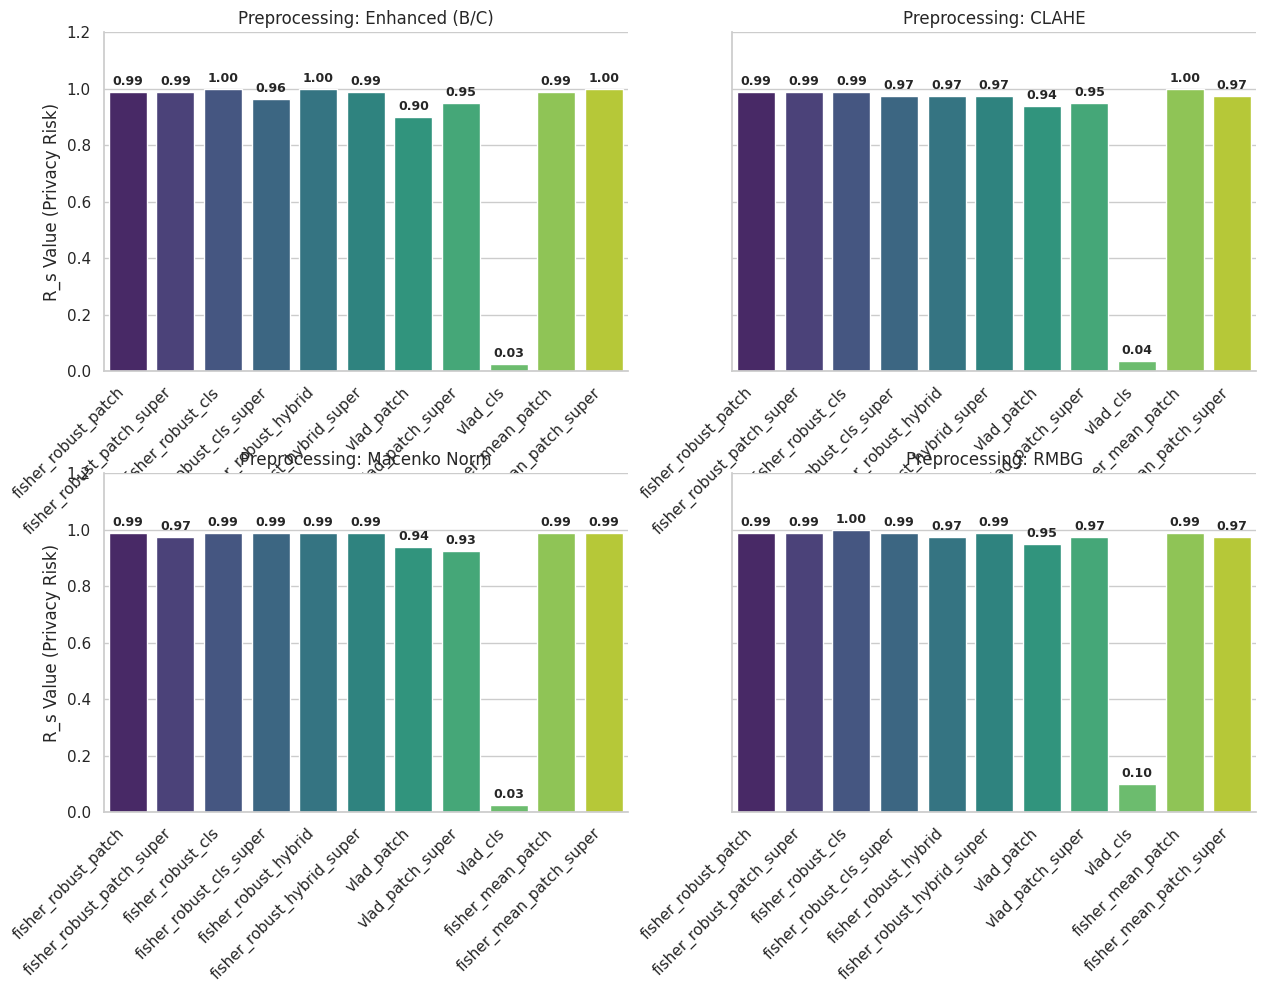

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. PŘÍPRAVA DAT (Stejná jako minule) ---
def cleanup_preprocessing_name(t):
    if "enhanced" in t: return "Enhanced (B/C)"
    if "clahe" in t: return "CLAHE"
    if "norm" in t: return "Macenko Norm"
    if "rmbg" in t: return "RMBG"
    return t

df_results['preprocessing'] = df_results['type'].apply(cleanup_preprocessing_name)

# --- 2. VIZUALIZACE S NEZÁVISLÝMI OSAMI X ---
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df_results, 
    kind="bar",
    x="method", 
    y="rs_value", 
    hue="method",           
    col="preprocessing",    
    col_wrap=2,             
    palette="viridis",
    height=6,               # Mírně zvětšíme výšku jednoho grafu
    aspect=1.2,
    sharex=False,           # ODSTRANÍ MEZERY (nezávislé osy X)
    legend=False            # Legendu vypneme, popíšeme osy přímo
)

# --- 3. FINÁLNÍ ÚPRAVY PRO LEPŠÍ ČITELNOST ---
for ax in g.axes.flat:
    # Přidání Rs hodnot nad sloupce
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')
    
    # OPRAVA 1: Otočení popisků o 45 stupňů a zarovnání doprava
    # (Metoda set_xticklabels je v novějším Seabornu doporučená přes tick_params, ale toto funguje spolehlivě)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Nastavení limitu Y
    ax.set_ylim(0, 1.2)

# Úprava titulků (nad každým oknem)
g.set_titles(col_template="Preprocessing: {col_name}")

# OPRAVA 2: Přidání popisků os. X necháme prázdnou, popsané jsou sloupce
g.set_axis_labels("", "R_s Value (Privacy Risk)")

# OPRAVA 3: KLÍČOVÝ KROK - Zvětšení prostoru pod grafem
# Musíme manuálně nastavit prostor, kam se vejdou rotované popisy.
plt.subplots_adjust(bottom=0.25, left=0.1, top=0.9, right=0.9, hspace=0.3, wspace=0.2) 

# plt.tight_layout() # Někdy tight_layout bojuje s subplots_adjust, raději ho vynecháme

plt.show()

In [1]:
import pandas as pd
import numpy as np
import re
import os
import pyarrow.parquet as pq
import faiss
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. FINÁLNÍ EXTRAKČNÍ LOGIKA ---
def extract_metadata_final(slide_id):
    # Dekódování URL (%2F -> /)
    sid_decoded = urllib.parse.unquote(str(slide_id))
    filename = sid_decoded.split('/')[-1].upper()
    
    # Filtry: Markery a Sub-řezy
    bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
    if any(m in filename for m in bad_markers):
        return None, None, "Marker"
    if re.search(r'(?:VEN|DORS|VENT)\d+-', filename):
        return None, None, "Sub-rez"

    # Extrakce čísla řezu (max 2 cifry, pravidlo 12)
    match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
    if match:
        num = int(match.group(1))
        if num >= 14: num = int(str(num)[0])
        
        # Pacient (číslo složky za annoPaperScanns)
        pat_match = re.search(r'annoPaperScanns/(\d+)/', sid_decoded)
        patient = pat_match.group(1) if pat_match else "Unknown"
        
        return patient, num, "OK"
    
    return None, None, "NoMatch"

# --- 2. FUNKCE PRO VÝPOČET STATISTIK ---
def get_decay_stats_from_clean_df(df_clean, embs_all, method_label, mpp_label, enc_label):
    if df_clean.empty: return []
    
    # Vybereme jen embeddingy pro "OK" řádky
    v_embs = embs_all[df_clean['orig_index'].values].astype('float32')
    faiss.normalize_L2(v_embs)
    
    # FAISS indexování
    index = faiss.IndexFlatIP(v_embs.shape[1])
    index.add(v_embs)
    _, faiss_indices = index.search(v_embs, 2)
    
    # Příprava pro Rs
    inventory = df_clean.groupby('patient_id')['section_num'].apply(set).to_dict()
    decay_entries = []

    # Procházíme výsledky hledání
    for i in range(len(df_clean)):
        neighbor_local_idx = faiss_indices[i, 1]
        row_q = df_clean.iloc[i]
        row_n = df_clean.iloc[neighbor_local_idx]
        
        if row_q['patient_id'] == row_n['patient_id']:
            dist = abs(row_q['section_num'] - row_n['section_num'])
            if 0 < dist <= 10:
                decay_entries.append(dist)

    # Výpočet Rs pro 1-12
    results = []
    for dist in range(1, 14):
        hits = decay_entries.count(dist)
        possible = sum(1 for pid, z_set in inventory.items() for z in z_set 
                      if any(abs(z - oz) == dist for oz in z_set if z != oz))
        
        results.append({
            "enc": enc_label, "mpp": mpp_label, "method": method_label,
            "section_dist": dist, "rs_val": hits/possible if possible > 0 else 0
        })
    return results

In [3]:

paths=[
    "/data/fs201053/jb88526/privagams_enc1_mpp10_enhanced_slides_final",
    "/data/fs201053/jb88526/privagams_enc1_mpp10_rmbg_clahe_slides_final",
    "/data/fs201053/jb88526/privagams_enc1_mpp10_rmbg_norm_slides_final",
    "/data/fs201053/jb88526/privagams_enc1_mpp10_rmbg_slides_final",
]

emb_col = [
    # --- FISHER ROBUST (HLAVNÍ) ---
    "fisher_robust_patch", 
    "fisher_robust_patch_super",
    "fisher_robust_cls",
    "fisher_robust_cls_super",
    "fisher_robust_hybrid",
    "fisher_robust_hybrid_super",
    "fisher_robust_default",
    "fisher_robust_default_super",
    
    # --- VLAD (PRO SROVNÁNÍ) ---
    "vlad_patch",
    "vlad_patch_super",
    "vlad_cls",
    "vlad_default",
    "vlad_default_super",
    
    # --- FISHER MEAN (DIAGNOSTIKA - volitelné) ---
    "fisher_mean_patch",
    "fisher_mean_patch_super",
    "fisher_mean_default"
]


In [ ]:
import pandas as pd
import numpy as np
import re
import os
import pyarrow.dataset as ds
import faiss
import urllib.parse
import gc

# --- 1. EXTRAKČNÍ LOGIKA (Zůstává stejná, jen přidána do loadu) ---
def extract_metadata_final(slide_id):
    sid_decoded = urllib.parse.unquote(str(slide_id))
    filename = sid_decoded.split('/')[-1].upper()
    bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
    if any(m in filename for m in bad_markers): return None, None, "Marker"
    if re.search(r'(?:VEN|DORS|VENT)\d+-', filename): return None, None, "Sub-rez"
    
    match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
    if match:
        num = int(match.group(1))
        if num >= 14: num = int(str(num)[0])
        pat_match = re.search(r'annoPaperScanns/(\d+)/', sid_decoded)
        patient = pat_match.group(1) if pat_match else "Unknown"
        return patient, num, "OK"
    return None, None, "NoMatch"

# --- 2. OPTIMALIZOVANÉ NAČÍTÁNÍ ---
def process_folder_safely(folder_path, emb_cols):
    dataset = ds.dataset(folder_path, format="parquet")
    
    # Načteme nejdřív jen slide_id, abychom udělali filtraci (šetříme RAM)
    ids_table = dataset.to_table(columns=["slide_id"])
    slide_ids = ids_table.column("slide_id").to_pylist()
    del ids_table
    
    clean_rows = []
    for i, sid in enumerate(slide_ids):
        p, n, status = extract_metadata_final(sid)
        if status == "OK":
            clean_rows.append({'orig_index': i, 'patient_id': p, 'section_num': n})
    
    df_clean = pd.DataFrame(clean_rows)
    if df_clean.empty:
        return None, None

    # Inventář pro výpočet "possible hits"
    inventory = df_clean.groupby('patient_id')['section_num'].apply(set).to_dict()
    
    results = []
    
    available_columns = dataset.schema.names # Seznam všech existujících sloupců
    
    for col in emb_cols:
        if col not in available_columns:
            print(f"  -> Přeskakuji {col}: Sloupec v datech neexistuje.")
            continue
        print(f"  -> Počítám metodu: {col}")
        # Načte jen JEDEN sloupec z disku
        col_table = dataset.to_table(columns=[col])
        # Převede na numpy bez .tolist() pastí
        embs_full = np.vstack(col_table.column(col).to_numpy()).astype('float32')
        del col_table
        
        # Vybereme jen ty profiltrované (Status OK)
        v_embs = embs_full[df_clean['orig_index'].values]
        del embs_full
        gc.collect()
        
        # FAISS search
        faiss.normalize_L2(v_embs)
        index = faiss.IndexFlatIP(v_embs.shape[1])
        index.add(v_embs)
        _, faiss_indices = index.search(v_embs, 2)
        
        # Decay analýza
        decay_entries = []
        for i in range(len(df_clean)):
            neighbor_idx = faiss_indices[i, 1]
            q = df_clean.iloc[i]
            n = df_clean.iloc[neighbor_idx]
            if q['patient_id'] == n['patient_id']:
                dist = abs(q['section_num'] - n['section_num'])
                if 0 < dist <= 13: decay_entries.append(dist)
        
        # Rs výpočet
        for dist in range(1, 14):
            hits = decay_entries.count(dist)
            possible = sum(1 for pid, z_set in inventory.items() for z in z_set 
                          if any(abs(z - oz) == dist for oz in z_set if z != oz))
            
            results.append({
                "mpp": os.path.basename(folder_path),
                "method": col,
                "section_dist": dist,
                "rs_val": hits/possible if possible > 0 else 0
            })
        
        del v_embs, index
        gc.collect()
        
    return results

# ... (všechny funkce zůstávají stejné)

# --- 3. SPUŠTĚNÍ ---
all_final_results = []
for path in paths:
    if not os.path.exists(path): 
        print(f"Cesta neexistuje: {path}")
        continue
    print(f"Zpracovávám: {path}")
    res = process_folder_safely(path, emb_col) # Opraveno na tvůj název 'emb_col'
    if res:
        all_final_results.extend(res)

Zpracovávám: /data/fs201053/jb88526/privagams_enc1_mpp10_enhanced_slides_final
  -> Počítám metodu: fisher_robust_patch
  -> Počítám metodu: fisher_robust_patch_super
  -> Počítám metodu: fisher_robust_cls
  -> Počítám metodu: fisher_robust_cls_super
  -> Počítám metodu: fisher_robust_hybrid
  -> Počítám metodu: fisher_robust_hybrid_super
  -> Přeskakuji fisher_robust_default: Sloupec v datech neexistuje.
  -> Přeskakuji fisher_robust_default_super: Sloupec v datech neexistuje.
  -> Počítám metodu: vlad_patch
  -> Počítám metodu: vlad_patch_super
  -> Počítám metodu: vlad_cls
  -> Přeskakuji vlad_default: Sloupec v datech neexistuje.
  -> Přeskakuji vlad_default_super: Sloupec v datech neexistuje.
  -> Počítám metodu: fisher_mean_patch
  -> Počítám metodu: fisher_mean_patch_super
  -> Přeskakuji fisher_mean_default: Sloupec v datech neexistuje.
Zpracovávám: /data/fs201053/jb88526/privagams_enc1_mpp10_rmbg_clahe_slides_final
  -> Počítám metodu: fisher_robust_patch
  -> Počítám metodu: 

NameError: name 'plt' is not defined

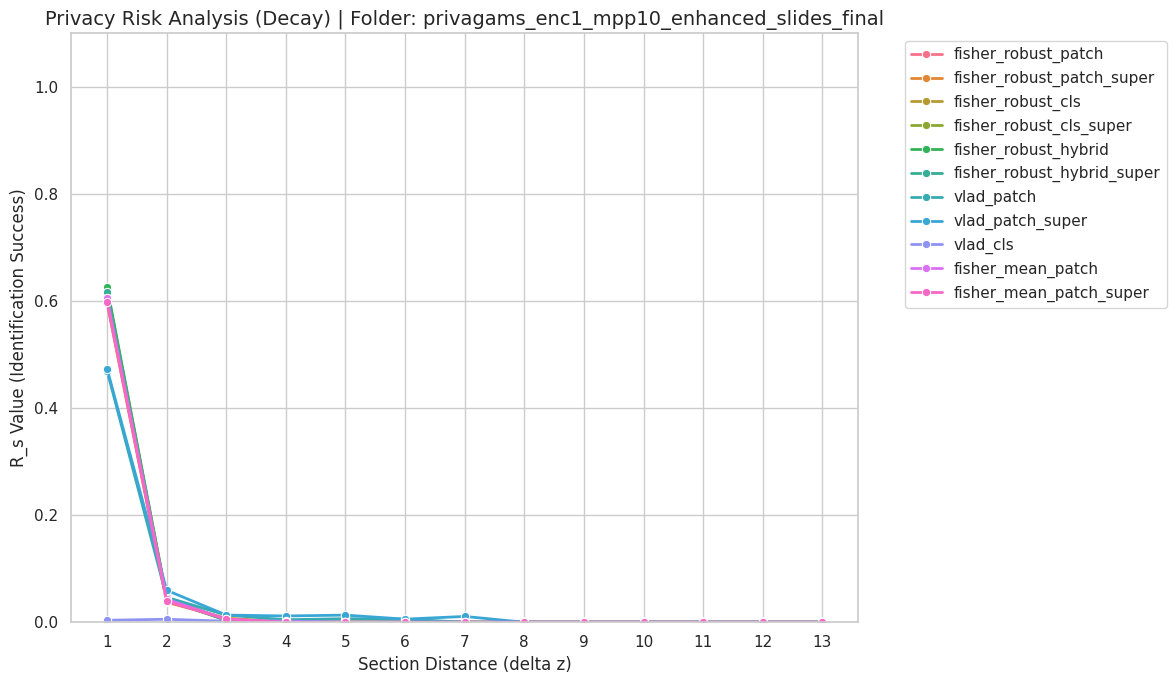

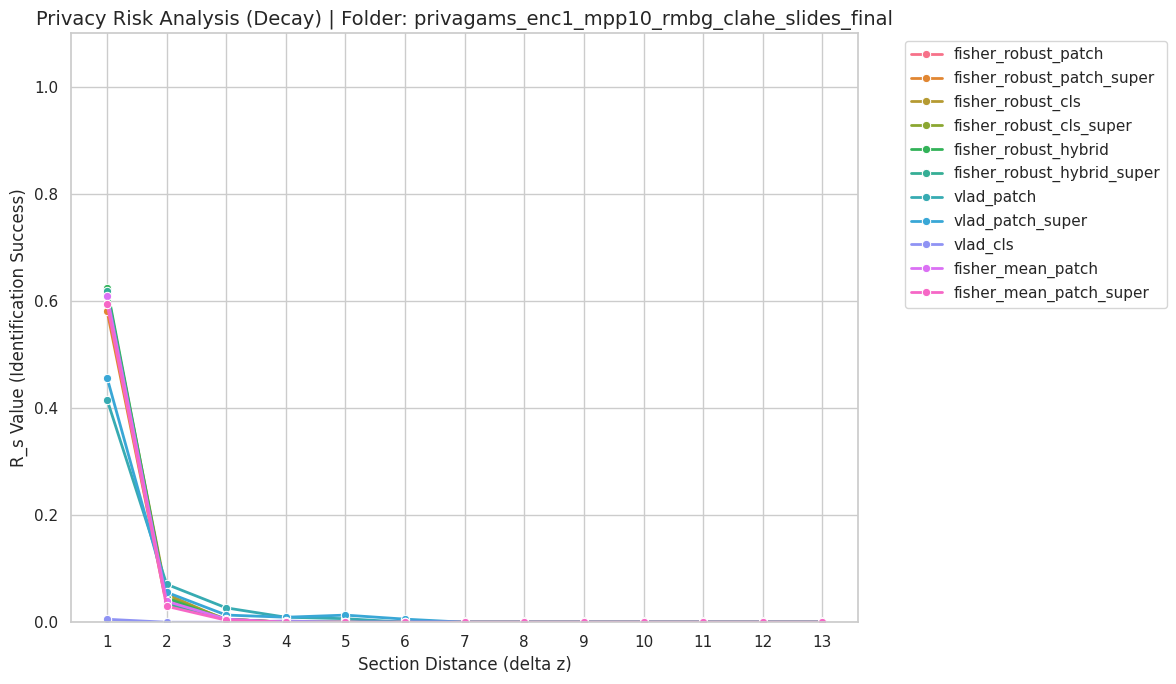

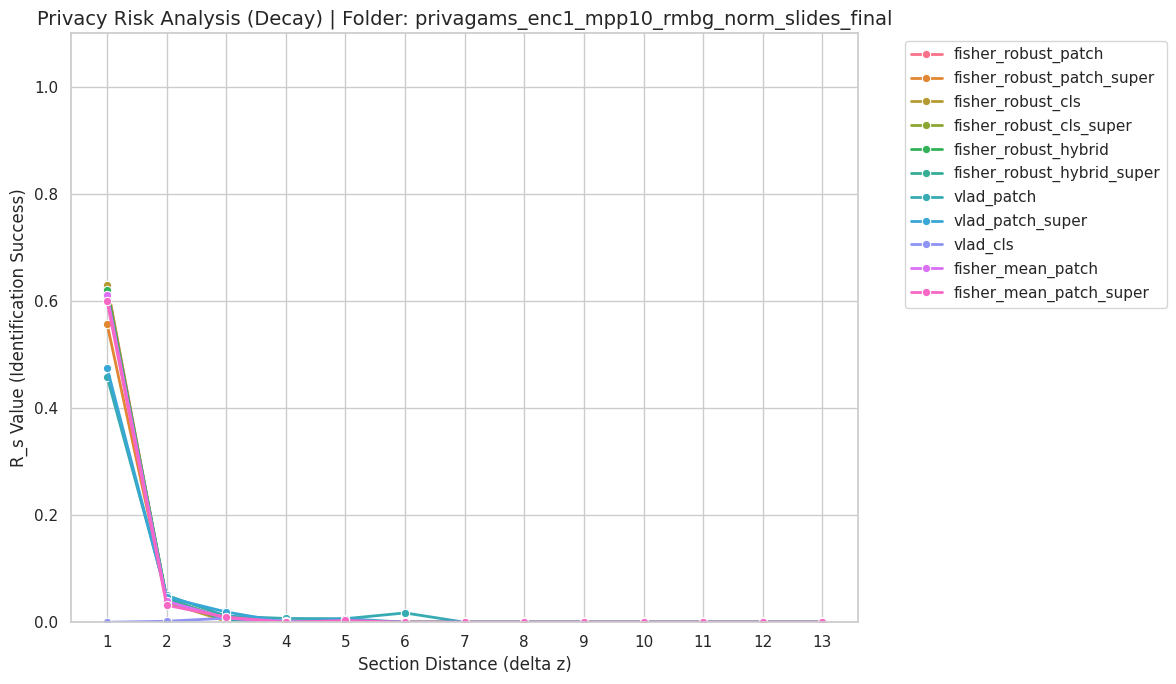

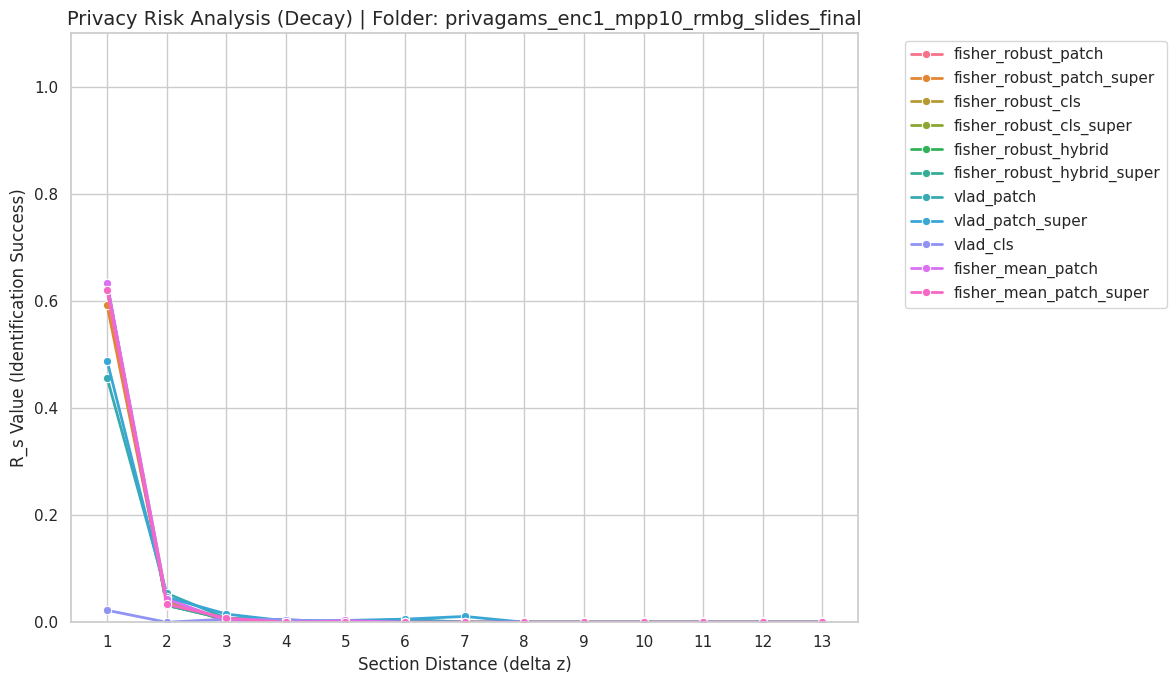

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 4. VYKRESLENÍ ---
if all_final_results: # Opraven název proměnné
    df_final = pd.DataFrame(all_final_results)
    
    # Pro každý MPP (složku) jeden graf
    for mpp in df_final['mpp'].unique():
        plt.figure(figsize=(12, 7))
        sns.set_theme(style="whitegrid")
        subset = df_final[df_final['mpp'] == mpp]
        
        sns.lineplot(data=subset, x="section_dist", y="rs_val", hue="method", marker="o", linewidth=2)
        
        plt.title(f"Privacy Risk Analysis (Decay) | Folder: {mpp}", fontsize=14)
        plt.ylabel("R_s Value (Identification Success)")
        plt.xlabel("Section Distance (delta z)")
        plt.ylim(0, 1.1)
        plt.xticks(range(1, 14))
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print("Žádná data k vykreslení. Zkontroluj, zda extrakce 'OK' proběhla v pořádku.")

# Different scanners

In [2]:
enc = ["0", "1", "2", "3"]
mpp = ["10"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
]

types = ["prostate", "breast", "colon"]


In [7]:
import urllib.parse
import re
import numpy as np
import pyarrow.parquet as pq
import faiss

def load_data_with_scanner_parsing(parquet_path, embedding_col="vlad_raw"):
    # Načtení tabulky
    table = pq.read_table(parquet_path, columns=[embedding_col, "__filename"])
    
    clean_embeddings = []
    clean_patient_ids = []
    clean_section_nums = []
    clean_scanners = []
    
    filenames = table.column("__filename").to_pylist()
    embeddings_list = table.column(embedding_col).to_pylist()

    for i in range(len(filenames)):
        # 1. Dekódování a vyčištění názvu
        decoded_path = urllib.parse.unquote(filenames[i])
        filename = decoded_path.split('/')[-1].upper()
        
        # 2. Filtry (markery)
        bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
        if any(m in filename for m in bad_markers):
            continue
            
        # 3. EXTRAKCE SCANNERU A PATIENT_ID
        # Regex vysvětlení:
        # ^([A-Z]+)       -> Najde počáteční písmena (MIDI, MIDITP, FLASH) - Skupina 1
        # .*?             -> Přeskočí případný nepořádek mezi tím
        # (\d{4}_.*?)     -> Najde rok a VŠE za ním až k příponě - Skupina 2
        # \.MRXS          -> Konec před příponou
        match = re.search(r'^([A-Z]+).*?(\d{4}_.*?)\.MRXS', filename)
        
        if match:
            raw_scanner = match.group(1)
            full_id_with_sections = match.group(2) # např. 2020_7590-01-0
            
            # --- OPRAVA ID ---
            # Odstraníme poslední pomlčku a cokoliv za ní (ten suffix -0 nebo -1)
            # rsplit('-', 1)[0] vezme vše před POSLEDNÍ pomlčkou
            clean_patient_id = full_id_with_sections.rsplit('-', 1)[0]
            
            # Sjednocení scanneru
            scanner = "FLASH" if "FLASH" in raw_scanner else "MIDI"
            
            # Extrakce čísla řezu (stále bereme to první číslo za pomlčkou)
            section_match = re.search(r'-(\d{1,2})', full_id_with_sections)
            if section_match:
                section_num = int(section_match.group(1))
                if section_num > 13: continue
            else:
                continue

            clean_embeddings.append(embeddings_list[i])
            # Teď ukládáme to očištěné ID (např. 2020_7590-01)
            clean_patient_ids.append(clean_patient_id) 
            clean_section_nums.append(section_num)
            clean_scanners.append(scanner)

    embeddings = np.array(clean_embeddings, dtype='float32')
    patient_ids = np.array(clean_patient_ids)
    section_nums = np.array(clean_section_nums)
    scanners = np.array(clean_scanners)
    
    if len(embeddings) > 0:
        faiss.normalize_L2(embeddings)
    
    print(f"File: {parquet_path.split('/')[-1]}")
    print(f"Sample Patient ID: {patient_ids[0] if len(patient_ids)>0 else 'N/A'}")
    print(f"Scanner: {np.unique(scanners)}")
    
    return patient_ids, section_nums, scanners, embeddings

In [8]:
def calculate_rs_cross_scanner(patient_ids, scanners, embeddings):
    """
    Počítá Rs tak, že pro každý obrázek ze skeneru A hledá nejbližšího souseda 
    v datech ze skeneru B a naopak.
    """
    import faiss
    import numpy as np

    unique_scanners = np.unique(scanners)
    if len(unique_scanners) < 2:
        print("Chyba: V datech je pouze jeden typ skeneru. Cross-scanner Rs nelze spočítat.")
        return 0.0

    # Rozdělení dat podle skenerů
    mask_a = (scanners == unique_scanners[0])
    mask_b = (scanners == unique_scanners[1])

    ids_a, embs_a = patient_ids[mask_a], embeddings[mask_a]
    ids_b, embs_b = patient_ids[mask_b], embeddings[mask_b]

    # 1. SMĚR: Sonda je ze skeneru A, hledáme v B
    index_b = faiss.IndexFlatIP(embs_b.shape[1])
    index_b.add(embs_b)
    _, indices_in_b = index_b.search(embs_a, 1) # Hledáme 1 nejbližší (sami tam nejsme)
    
    # 2. SMĚR: Sonda je ze skeneru B, hledáme v A
    index_a = faiss.IndexFlatIP(embs_a.shape[1])
    index_a.add(embs_a)
    _, indices_in_a = index_a.search(embs_b, 1)

    # Vyhodnocení úspěšnosti (Sonda ID == Soused ID)
    correct_a_to_b = (ids_a == ids_b[indices_in_b.flatten()])
    correct_b_to_a = (ids_b == ids_a[indices_in_a.flatten()])

    # Sjednocení zranitelných pacientů (pacient je zranitelný, pokud byl 
    # identifikován alespoň v jednom směru)
    vulnerable_patients = set()
    
    # Pacienti identifikovaní ze skeneru A v B
    for i in range(len(ids_a)):
        if correct_a_to_b[i]:
            vulnerable_patients.add(ids_a[i])
            
    # Pacienti identifikovaní ze skeneru B v A
    for i in range(len(ids_b)):
        if correct_b_to_a[i]:
            vulnerable_patients.add(ids_b[i])

    all_patients = set(patient_ids)
    num_vulnerable = len(vulnerable_patients)
    total_patients = len(all_patients)
    rs = num_vulnerable / total_patients if total_patients > 0 else 0

    print(f"--- Výsledek Cross-Scanner Rs ({unique_scanners[0]} <-> {unique_scanners[1]}) ---")
    print(f"Celkem unikátních pacientů: {total_patients}")
    print(f"Zranitelných pacientů napříč skenery: {num_vulnerable}")
    print(f"Finální Cross-R_s: {rs:.4f}")

    return rs

In [9]:
import gc
import pandas as pd
import os

results_data = []    # Pro souhrnné Rs
detail_records = []  # Pro podrobný seznam cest a ID

for e in enc:
    for t in types:
        current_path = f"/mnt/projects/ri_scale/privagams/{t}_enc{e}_slides_v4"
        
        if not os.path.exists(current_path):
            continue
            
        for col in emb_col:
            print(f"Processing: ENC={e}, TYPE={t}, COL={col}...")
            
            try:
                # 1. Načtení dat (používá tvou funkci s regexem)
                pids, s_nums, scns, embs = load_data_with_scanner_parsing(current_path, col)
                unique_pids, counts = np.unique(pids, return_counts=True)
                print(f"\n--- SEZNAM NALEZENÝCH PACIENTŮ (Celkem: {len(unique_pids)}) ---")
                for pid, count in zip(unique_pids, counts):
                    # Najdeme scannery, které tento konkrétní pacient má
                    p_scanners = np.unique(scns[pids == pid])
                    print(f"ID: {pid:<20} | Počet řezů: {count:<3} | Scannery: {p_scanners}")
                # 2. Uložení DETAILŮ (pro každý řez jeden řádek v seznamu)
                # Tohle ti udělá ten přehledný seznam, co chceš
                for i in range(len(pids)):
                    detail_records.append({
                        "encoder": f"ENC_{e}",
                        "tissue_type": t,
                        "method": col,
                        "patient_id": pids[i],
                        "scanner": scns[i],
                        "section_num": s_nums[i],
                        "source_folder": current_path
                    })

                # 3. Výpočet Rs (Cross-Scanner)
                rs_val = calculate_rs_cross_scanner(pids, scns, embs)
                
                results_data.append({
                    "enc": f"Encoder {e}",
                    "method": col,
                    "rs_value": rs_val,
                    "type": t
                })

                # Úklid paměti
                del embs
                gc.collect()    
                
            except Exception as ex:
                print(f"Chyba u {current_path}, {col}: {ex}")

# Finální DataFrame pro detailní seznam
df_detail = pd.DataFrame(detail_records)

# Finální DataFrame pro grafy
df_results = pd.DataFrame(results_data)

# Ukázka, jak vypadá ten detailní seznam
print("\nUkázka detailního seznamu (prvních 5 řádků):")
print(df_detail[['patient_id', 'scanner', 'section_num']].head())

# Volitelně uložení do CSV, abys na to mohl koukat v Excelu
df_detail.to_csv("analyza_identit_detail.csv", index=False)

Processing: ENC=0, TYPE=prostate, COL=vlad_default...
File: prostate_enc0_slides_v4
Sample Patient ID: 2020_6561-01
Scanner: ['FLASH' 'MIDI']

--- SEZNAM NALEZENÝCH PACIENTŮ (Celkem: 10) ---
ID: 2020_6561-01         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2020_7141-04         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2020_7317-10         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2020_7590-01         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2021_4979-07         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2021_5116-03         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2021_5614-06         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2021_5718-10         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2021_5719-01         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
ID: 2021_5803-07         | Počet řezů: 2   | Scannery: ['FLASH' 'MIDI']
--- Výsledek Cross-Scanner Rs (FLASH <-> MIDI) ---
Celkem unikátních pacientů: 10
Zranite

In [21]:
df_results.to_csv("test.csv")

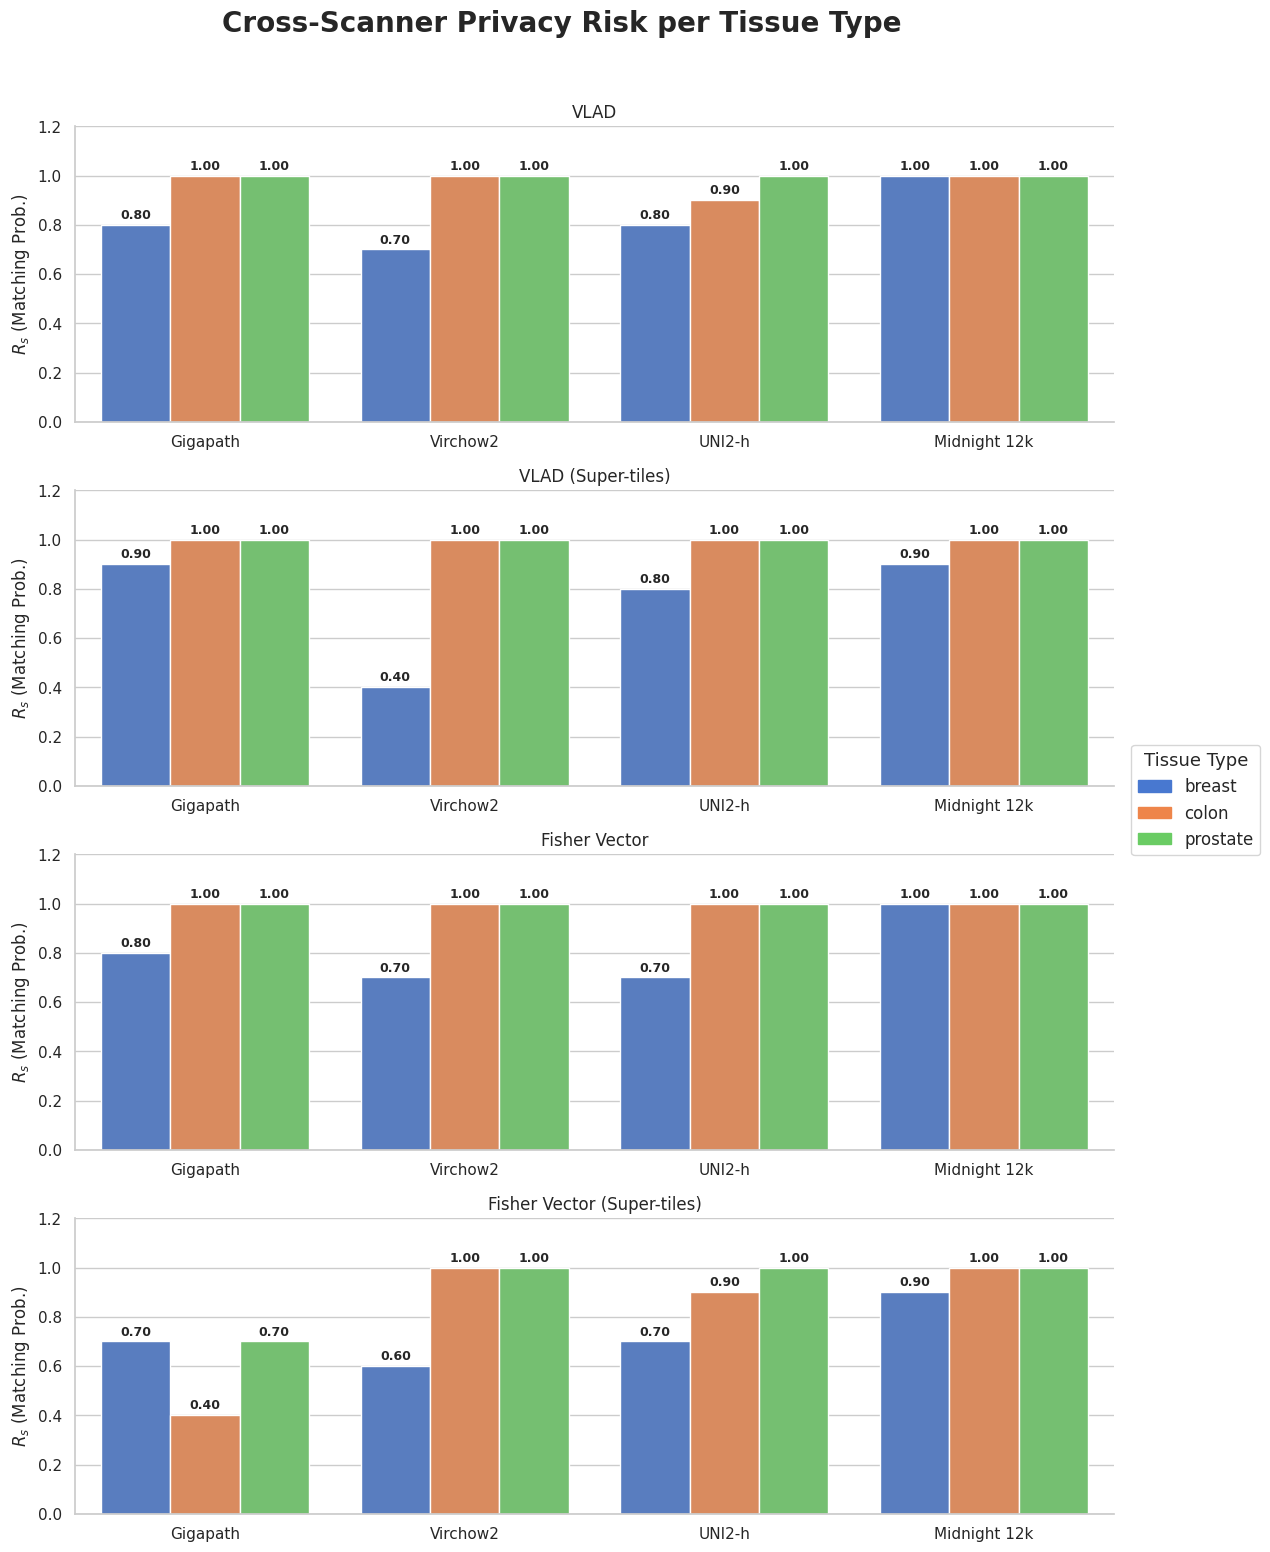

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

if not df_results.empty:
    # --- 1. MAPOVÁNÍ NOVÝCH NÁZVŮ ---
    nice_method_names = {
        "vlad_default": "VLAD",
        "vlad_default_super": "VLAD (Super-tiles)",
        "fisher_default": "Fisher Vector",
        "fisher_default_super": "Fisher Vector (Super-tiles)"
    }
    
    # Aktualizované názvy enkodérů
    nice_encoder_names = {
        "Encoder 0": "Gigapath",
        "Encoder 1": "Virchow2",
        "Encoder 2": "UNI2-h",
        "Encoder 3": "Midnight 12k"
    }

    df_results['method_nice'] = df_results['method'].map(nice_method_names).fillna(df_results['method'])
    df_results['encoder_name'] = df_results['enc'].map(nice_encoder_names).fillna(df_results['enc'])
    
    # Seřazení
    methods_order = ["VLAD", "VLAD (Super-tiles)", "Fisher Vector", "Fisher Vector (Super-tiles)"]
    df_results['method_nice'] = pd.Categorical(df_results['method_nice'], categories=methods_order, ordered=True)
    df_results = df_results.sort_values(['method_nice', 'enc'])

    # --- 2. GRAF ---
    sns.set_theme(style="whitegrid")
    
    g = sns.catplot(
        data=df_results,
        x="encoder_name", 
        y="rs_value", 
        col="method_nice", 
        hue="type",
        kind="bar", 
        height=3.8, 
        aspect=3.0,
        col_wrap=1, 
        sharey=True,
        sharex=False,   # Důležité: umožní nezávislé osy X
        palette="muted",
        errorbar=None,
        legend=False
    )

    g.set_titles(col_template="{col_name}")
    g.set_ylabels("$R_s$ (Matching Prob.)")
    
    # --- 3. ÚPRAVA KAŽDÉ OSY ZVLÁŠŤ ---
    for ax in g.axes.flat:
        ax.set_ylim(0, 1.2)
        
        # Vynucení popisků osy X pod KAŽDÝM grafem
        ax.tick_params(labelbottom=True)
        ax.set_xlabel("", fontsize=11)
        
        # Hodnoty nad sloupce
        for p in ax.patches:
            val = p.get_height()
            if val > 0:
                ax.annotate(f'{val:.2f}', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 7), 
                            textcoords='offset points', 
                            fontsize=9, fontweight='bold')

    # --- 4. LEGENDA A TITULEK ---
    # Legendu dáme doprava nahoru, aby nezavazela
    palette = sns.color_palette("muted")
    tissues = sorted(df_results['type'].unique())
    patches = [mpatches.Patch(color=palette[i], label=t) for i, t in enumerate(tissues)]
    
    # Použijeme g.fig.legend pro umístění vzhledem k celému obrázku
    g.fig.legend(
        handles=patches,
        title="Tissue Type",
        loc='center right',          # Umístění vpravo uprostřed
        bbox_to_anchor=(1.12, 0.5),   # x=1.12 (vpravo za grafy), y=0.5 (střed výšky)
        ncol=1, 
        fontsize=12,
        title_fontsize=13,
        frameon=True
    )

    plt.suptitle("Cross-Scanner Privacy Risk per Tissue Type", 
                 fontsize=20, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()